# Gradient Boosting (XGBoost / LightGBM) segmentation of spectrogram-derived features

This notebook trains a **tree-based classifier** (XGBoost or LightGBM) to predict a **binary mask** over time. We treat segmentation as **time-bin classification** (one row per time index), and compute **Dice per recording/window**.

# load Dataset

In [16]:
process = True

In [17]:
import os
import numpy as np
import json
from pathlib import Path

def load_mask_with_spectrograms(path: str | Path) -> dict:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


if process == True:

    # List all elements (files and folders)
    elements = os.listdir('data_mask_spectro/')

    X_eeg =  []
    X_spec = []
    Y = []

    for elem in elements:
        if '.json' in elem:
            # load masks and spectrogram
            data = load_mask_with_spectrograms('data_mask_spectro/' + elem)
            # load recording (use try except since can be from 2 different folders)
            try:
                y = np.load('anesthesia_database/' + data['recording'])
            except:
                y = np.load('anesthesia_database_Trousseau/' + data['recording'])
            # load window key names
            list_windows_keys = list(data['windows'].keys())
            # iterate over all windows
            for i in range(len(data['windows'])):
                current_window = data['windows'][list_windows_keys[i]]
                start_s = float(current_window["window_start_s"])
                end_s = float(current_window["window_end_s"])
                fs = int(current_window["fs_hz"])

                start_i = int(round(start_s * fs))
                end_i = int(round(end_s * fs))

                signal = y[start_i : end_i]
                t_signal = np.arange(len(signal)) / fs

                mask = current_window['mask']

                t_spec = current_window['t_spec']
                f_spec = current_window['f_spec']
                spec = np.array(current_window['spectrogram'])

                X_eeg.append(signal)
                X_spec.append(spec)
                Y.append(mask)


    #--- convert to np arrays
    X_eeg = np.array(X_eeg)
    X_spec = np.array(X_spec)
    Y = np.array(Y)

    np.save('X_Y_dataset/X_eeg', X_eeg)
    np.save('X_Y_dataset/X_spec', X_spec)
    np.save('X_Y_dataset/Y', Y)

else:
    X_eeg =  np.load('X_Y_dataset/X_eeg.npy')
    X_spec =  np.load('X_Y_dataset/X_spec.npy')
    Y = np.load('X_Y_dataset/Y.npy')
    X = np.load('X_Y_dataset/X_features.npy')

# Get features and X, Y vectors

In [18]:
features = ['mean', 'med_mean',
            'q_std', 'med_q_std',
            'q_linelen', 'med_linelen',
            'q_env', 'med_q_env',
            'q_std_env', 'q_std_env',
            'ef', 'ef_recovery','med_ef','med_ef_recovery',
            'prop_delta', 'prop_alpha', 'prop_beta', 'prop_gamma',
            'q_P_tot', 'med_q_P_tot'
            ]

In [19]:
from feature_extractor import extract_features_time_series, extract_features_spectrogram

X = []

fs  = 128
for i in range(len(Y)):
    mean, med_mean, q_std, med_q_std, q_linelen, med_q_linelen, q_env, med_q_env, q_std_env, med_q_std_env  = extract_features_time_series(X_eeg[i], int(fs / 8), Y[i])
    ef, ef_recovery, med_ef, med_ef_recovery, prop_delta, prop_alpha, prop_beta, prop_gamma, q_P_tot, med_q_P_tot =  extract_features_spectrogram(np.array(f_spec), X_spec[i])
    X.append([mean, med_mean, q_std, med_q_std, q_linelen, med_q_linelen, q_env, med_q_env, q_std_env, med_q_std_env, ef, ef_recovery, med_ef, med_ef_recovery, prop_delta, prop_alpha, prop_beta, prop_gamma, q_P_tot, med_q_P_tot])

np.save('X_Y_dataset/X_features', X)

c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:362: RuntimeWarning: invalid value encountered in divide
  prop_delta = P_delta / P_tot
c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:363: RuntimeWarning: invalid value encountered in divide
  prop_alpha = P_alpha/ P_tot
c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:364: RuntimeWarning: invalid value encountered in divide
  prop_beta = P_beta / P_tot
c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:365: RuntimeWarning: invalid value encountered in divide
  prop_gamma = P_gamma / P_tot


# Utilities

# Train / Val / Test split + tabular formatting (time-bin classification)

We convert each recording/window into tabular rows:
- each time index `t` is one training example
- features are the values at `t` (optionally with lagged values)
- `group_id` tracks which recording/window each row came from, so we can compute **Dice per recording** and split without leakage.

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Optional: XGBoost / LightGBM
import xgboost as xgb
import lightgbm as lgb

def dice_binary(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    """Dice for binary arrays (0/1)."""
    y_true = y_true.astype(np.bool_)
    y_pred = y_pred.astype(np.bool_)
    inter = np.logical_and(y_true, y_pred).sum()
    denom = y_true.sum() + y_pred.sum()
    return float((2.0 * inter + eps) / (denom + eps))

def dice_multiclass_macro(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int, ignore_classes: set[int] | None = None) -> float:
    """Macro-average Dice across classes for a single sequence."""
    if ignore_classes is None:
        ignore_classes = set()
    dices = []
    for c in range(num_classes):
        if c in ignore_classes:
            continue
        a = (y_true == c)
        b = (y_pred == c)
        inter = np.logical_and(a, b).sum()
        denom = a.sum() + b.sum()
        d = (2.0 * inter) / denom if denom > 0 else 1.0
        dices.append(d)
    return float(np.mean(dices)) if len(dices) else float("nan")

def dice_multiclass_per_group(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    group_id: np.ndarray,
    num_classes: int,
    ignore_classes: set[int] | None = None,
) -> pd.DataFrame:
    """Return macro Dice per group_id (recording/window)."""
    if ignore_classes is None:
        ignore_classes = set()
    rows = []
    # IMPORTANT: preserve dataset order (same as DL) for deterministic comparisons
    for g in pd.unique(group_id):
        m = group_id == g
        yt = y_true[m].astype(int)
        yp = y_pred[m].astype(int)
        md = dice_multiclass_macro(yt, yp, num_classes=num_classes, ignore_classes=ignore_classes)
        rows.append((int(g), md, int(m.sum())))
    df = pd.DataFrame(rows, columns=["group_id", "macro_dice", "T"])
    return df

def build_tabular_from_time_series(
    X_list,
    Y_list,
    add_lags: bool = False,
    lags: tuple[int, ...] = (1, 2, 4, 8),
):
    """Convert list-of-recordings into a 2D tabular matrix for boosting.

    Expected input format (per recording r):
      - X_list[r] is a list/tuple of N feature time series, each length T_r
        OR a numpy array shaped (N, T_r) or (T_r, N)
      - Y_list[r] is the mask array length T_r (0/1 or ints)

    Output:
      - X_tab: (sum_r T_r, num_features)
      - y_tab: (sum_r T_r,)
      - group_id: (sum_r T_r,) integer recording id
      - time_id: (sum_r T_r,) time index within recording
      - feature_names: list[str]
    """
    X_rows = []
    y_rows = []
    g_rows = []
    t_rows = []
    feature_names = None

    for g, (Xr, yr) in enumerate(zip(X_list, Y_list)):
        yr = np.asarray(yr).astype(int).ravel()
        T = len(yr)

        # Convert Xr to array shape (T, N)
        if isinstance(Xr, (list, tuple)):
            # list of N arrays length T
            Xr_arr = np.vstack([np.asarray(f).ravel() for f in Xr]).T  # (T, N)
        else:
            Xr_arr = np.asarray(Xr)
            if Xr_arr.ndim != 2:
                raise ValueError(f"X[{g}] must be 2D-like. Got shape {Xr_arr.shape}")
            # If (N, T) convert to (T, N)
            if Xr_arr.shape[0] != T and Xr_arr.shape[1] == T:
                Xr_arr = Xr_arr.T
            if Xr_arr.shape[0] != T:
                raise ValueError(f"X[{g}] time length mismatch: mask T={T}, X shape={Xr_arr.shape}")

        N = Xr_arr.shape[1]
        if feature_names is None:
            feature_names = [f"f{i:02d}" for i in range(N)]

        cols = [Xr_arr]
        names = feature_names.copy()

        if add_lags:
            for L in lags:
                lagged = np.full_like(Xr_arr, np.nan, dtype=float)
                if L < T:
                    lagged[L:, :] = Xr_arr[:-L, :]
                cols.append(lagged)
                names.extend([f"{fn}_lag{L}" for fn in feature_names])

        Xr_feat = np.concatenate(cols, axis=1).astype(float)  # (T, N*(1+len(lags)))
        X_rows.append(Xr_feat)
        y_rows.append(yr)
        g_rows.append(np.full(T, g, dtype=int))
        t_rows.append(np.arange(T, dtype=int))

    X_tab = np.concatenate(X_rows, axis=0)
    y_tab = np.concatenate(y_rows, axis=0)
    group_id = np.concatenate(g_rows, axis=0)
    time_id = np.concatenate(t_rows, axis=0)
    return X_tab, y_tab, group_id, time_id, names


## Build `X_tab`, `y_tab`, `group_id` (with optional lags)

Set `ADD_LAGS=True` to include lagged feature values. This is often important because boosting models do not *implicitly* learn temporal context like CNNs/Transformers.

In [21]:
# X was built earlier as a list of per-recording feature time series (saved to X_Y_dataset/X_features.npy)
# If you already reloaded X in the 'else' branch, X may be a numpy object array. We normalize it to a Python list.

# Ensure X is a list of recordings
if isinstance(X, np.ndarray) and X.dtype == object:
    X_list = list(X)
else:
    X_list = X

Y_list = list(Y) if isinstance(Y, np.ndarray) else Y

ADD_LAGS = False  # <-- compare False vs True
LAGS = (1, 2, 4, 8)

X_tab, y_tab, group_id, time_id, feature_names = build_tabular_from_time_series(
    X_list, Y_list, add_lags=ADD_LAGS, lags=LAGS
)

print("X_tab:", X_tab.shape, " y_tab:", y_tab.shape)
print("#groups:", len(np.unique(group_id)), " positives:", int(y_tab.sum()), " pos_rate:", float(y_tab.mean()))
print("#features:", len(feature_names))


X_tab: (123552, 20)  y_tab: (123552,)
#groups: 416  positives: 215961  pos_rate: 1.7479360916860918
#features: 20


## Train / Val / Test split by `group_id` (same proportions as the DL notebook)

In the DL notebook, the split is performed **at the recording/window level** using `train_test_split`:
- `test_size=0.2`
- then `val_size=0.2` of the remaining data

That yields **Train 64% / Val 16% / Test 20%**.

Here we do the same, but explicitly on `group_id` to prevent leakage (all time bins from a recording stay in the same split).


In [22]:

# Split groups: Train / Val / Test using the SAME logic as the DL notebook
# DL: test_size=0.2, then val_size=0.2 of remaining -> Train 64%, Val 16%, Test 20%

from sklearn.model_selection import train_test_split

rng = 42
# IMPORTANT: preserve original recording/window order so splits match the DL notebook exactly
# (np.unique would SORT ids and change the split even with the same random_state)
g_unique = pd.unique(group_id)
g_unique = np.asarray(g_unique)

g_temp, g_test = train_test_split(
    g_unique,
    test_size=0.2,
    random_state=rng,
    shuffle=True,
    stratify=None
)

g_train, g_val = train_test_split(
    g_temp,
    test_size=0.2,   # 20% of remaining -> 16% of total
    random_state=rng,
    shuffle=True,
    stratify=None
)

train_mask = np.isin(group_id, g_train)
val_mask   = np.isin(group_id, g_val)
test_mask  = np.isin(group_id, g_test)

X_train, y_train, gid_train = X_tab[train_mask], y_tab[train_mask], group_id[train_mask]
X_val,   y_val,   gid_val   = X_tab[val_mask],   y_tab[val_mask],   group_id[val_mask]
X_test,  y_test,  gid_test  = X_tab[test_mask],  y_tab[test_mask],  group_id[test_mask]

print("Groups:", len(g_unique), "-> train/val/test:", len(g_train), len(g_val), len(g_test))
print("Rows:", X_tab.shape[0], "-> train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Positive rate (train/val/test):",
      y_train.mean().round(4), y_val.mean().round(4), y_test.mean().round(4))


Groups: 416 -> train/val/test: 265 67 84
Rows: 123552 -> train/val/test: 78705 19899 24948
Positive rate (train/val/test): 1.8449 1.5007 1.6393


## Train XGBoost (default)

We train with **binary logloss** (standard for boosting). We then choose a **decision threshold** that maximizes **mean Dice per recording** on validation.

In [23]:
# ----------------------------
# Train XGBoost (MULTICLASS baseline) + OPTIONAL two-stage pipeline:
#   Stage A: background (0) vs non-background (1..K-1)
#   Stage B: classify among non-background classes (1..K-1)
# We keep group_id-based split so you can compare fairly with DL.
# ----------------------------
from sklearn.utils.class_weight import compute_class_weight

# Infer number of classes from data (or set explicitly)
NUM_CLASSES = int(np.max(y_train)) + 1
print("NUM_CLASSES:", NUM_CLASSES)

# Optional: treat class 0 as background and ignore it in macro-Dice
IGNORE_CLASSES_FOR_DICE = {}  # set to set() if you want to include background

# Toggle: choose which predictions are used downstream (confusion matrix + mask viz)
USE_TWO_STAGE = True

# -----------------------------------------------------------------------------
# Baseline: single-stage multiclass
# -----------------------------------------------------------------------------
# Class imbalance handling (analogous to class-weighted CE in DL):
# use balanced class weights -> per-sample weights
classes = np.arange(NUM_CLASSES, dtype=int)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.astype(int))
class_weight = dict(zip(classes, cw))
w_train_mc = np.vectorize(class_weight.get)(y_train.astype(int)).astype(float)
print("Baseline multiclass class weights:", class_weight)

xgb_mc = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

xgb_mc.fit(
    X_train, y_train.astype(int),
    sample_weight=w_train_mc,
    eval_set=[(X_val, y_val.astype(int))],
    verbose=False,
)

p_val_mc = xgb_mc.predict_proba(X_val)
p_test_mc = xgb_mc.predict_proba(X_test)

yhat_val_mc = np.argmax(p_val_mc, axis=1).astype(int)
yhat_test_mc = np.argmax(p_test_mc, axis=1).astype(int)

df_val_mc = dice_multiclass_per_group(y_val, yhat_val_mc, gid_val, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)
df_test_mc = dice_multiclass_per_group(y_test, yhat_test_mc, gid_test, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)

print("\n[Baseline multiclass]")
print("Val macro Dice (mean over recordings):", float(df_val_mc["macro_dice"].mean()), " median:", float(df_val_mc["macro_dice"].median()))
print("Test macro Dice (mean over recordings):", float(df_test_mc["macro_dice"].mean()), " median:", float(df_test_mc["macro_dice"].median()))

# -----------------------------------------------------------------------------
# Two-stage: A) event detector (0 vs non-0) then B) subtype (1..K-1)
# -----------------------------------------------------------------------------
if NUM_CLASSES <= 2:
    print("\nTwo-stage pipeline skipped because NUM_CLASSES <= 2.")
    USE_TWO_STAGE = False
else:
    # ---- Stage A: background vs non-background ----
    yA_train = (y_train.astype(int) != 0).astype(int)
    yA_val = (y_val.astype(int) != 0).astype(int)
    yA_test = (y_test.astype(int) != 0).astype(int)

    # scale_pos_weight is appropriate for binary imbalance (non-bg is often rare)
    pos = float(yA_train.sum())
    neg = float((1 - yA_train).sum())
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    print("\n[Two-stage] Stage A scale_pos_weight:", scale_pos_weight)

    xgb_A = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=1.0,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

    xgb_A.fit(
        X_train, yA_train,
        eval_set=[(X_val, yA_val)],
        verbose=False,
    )

    pA_val = xgb_A.predict_proba(X_val)[:, 1]
    pA_test = xgb_A.predict_proba(X_test)[:, 1]

    # ---- Stage B: classify among classes 1..K-1 (train only on non-background bins) ----
    nonbg_train = (y_train.astype(int) != 0)
    nonbg_val = (y_val.astype(int) != 0)
    nonbg_test = (y_test.astype(int) != 0)

    X_train_B = X_train[nonbg_train]
    y_train_B = (y_train.astype(int)[nonbg_train] - 1)  # {1..K-1} -> {0..K-2}

    X_val_B = X_val[nonbg_val]
    y_val_B = (y_val.astype(int)[nonbg_val] - 1)

    NUM_B = NUM_CLASSES - 1
    classesB = np.arange(NUM_B, dtype=int)

    cwB = compute_class_weight(class_weight="balanced", classes=classesB, y=y_train_B.astype(int))
    class_weight_B = dict(zip(classesB, cwB))
    w_train_B = np.vectorize(class_weight_B.get)(y_train_B.astype(int)).astype(float)

    print("[Two-stage] Stage B class weights (mapped 0..K-2 for original 1..K-1):", class_weight_B)

    xgb_B = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=NUM_B,
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=1.0,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )

    xgb_B.fit(
        X_train_B, y_train_B.astype(int),
        sample_weight=w_train_B,
        eval_set=[(X_val_B, y_val_B.astype(int))],
        verbose=False,
    )

    # Precompute Stage B probabilities for ALL bins (so threshold search is cheap)
    pB_val_all = xgb_B.predict_proba(X_val)   # shape (n_val, NUM_B)
    pB_test_all = xgb_B.predict_proba(X_test) # shape (n_test, NUM_B)

    def combine_two_stage(pA, pB_all, tau):
        """Return final yhat in original label space {0..K-1}."""
        yhat = np.zeros(len(pA), dtype=int)  # default background
        idx = np.where(pA >= tau)[0]
        if len(idx) > 0:
            yB = np.argmax(pB_all[idx], axis=1).astype(int) + 1  # back to {1..K-1}
            yhat[idx] = yB
        return yhat

    # Tune tau on validation to maximize mean macro-Dice per recording/window
    grid = np.linspace(0.05, 0.95, 91)  # step 0.01
    best = (-1.0, 0.5)
    for tau in grid:
        yhat_tmp = combine_two_stage(pA_val, pB_val_all, tau)
        df_tmp = dice_multiclass_per_group(y_val, yhat_tmp, gid_val, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)
        md = float(df_tmp["macro_dice"].mean())
        if md > best[0]:
            best = (md, float(tau))

    best_md_2s, best_tau = best
    print("\n[Two-stage] Best val macro-Dice:", best_md_2s, "at tau:", best_tau)

    # Final two-stage predictions using best tau
    yhat_val_2s = combine_two_stage(pA_val, pB_val_all, best_tau)
    yhat_test_2s = combine_two_stage(pA_test, pB_test_all, best_tau)

    df_val_2s = dice_multiclass_per_group(y_val, yhat_val_2s, gid_val, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)
    df_test_2s = dice_multiclass_per_group(y_test, yhat_test_2s, gid_test, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)

    print("[Two-stage]")
    print("Val macro Dice (mean over recordings):", float(df_val_2s["macro_dice"].mean()), " median:", float(df_val_2s["macro_dice"].median()))
    print("Test macro Dice (mean over recordings):", float(df_test_2s["macro_dice"].mean()), " median:", float(df_test_2s["macro_dice"].median()))

# -----------------------------------------------------------------------------
# Choose predictions for downstream cells (confusion matrix + mask visualization)
# -----------------------------------------------------------------------------
if USE_TWO_STAGE and "yhat_test_2s" in globals():
    yhat_val = yhat_val_2s
    yhat_test = yhat_test_2s
    print("\nUsing TWO-STAGE predictions downstream (yhat_val, yhat_test).")
else:
    yhat_val = yhat_val_mc
    yhat_test = yhat_test_mc
    print("\nUsing BASELINE multiclass predictions downstream (yhat_val, yhat_test).")


NUM_CLASSES: 10
Baseline multiclass class weights: {0: 0.18043328748280604, 1: 2.34870188003581, 2: 0.9865254449736777, 3: 2.5388709677419357, 4: 0.9477962427745664, 5: 1.5179363548698168, 6: 5.740700218818381, 7: 47.7, 8: 3.020145817344589, 9: 2.601818181818182}

[Baseline multiclass]
Val macro Dice (mean over recordings): 0.7595252072745556  median: 0.7877698731828023
Test macro Dice (mean over recordings): 0.748242512508022  median: 0.7826524608425707

[Two-stage] Stage A scale_pos_weight: 1.2432663531423684
[Two-stage] Stage B class weights (mapped 0..K-2 for original 1..K-1): {0: 1.1633343280612753, 1: 0.4886354140553188, 2: 1.2575268817204301, 3: 0.46945247270391777, 4: 0.7518482802957248, 5: 2.8434232920009723, 6: 23.626262626262626, 7: 1.495906881555385, 8: 1.2887052341597796}

[Two-stage] Best val macro-Dice: 0.8239890412895083 at tau: 0.95
[Two-stage]
Val macro Dice (mean over recordings): 0.8239890412895083  median: 0.8559169377032774
Test macro Dice (mean over recordings): 

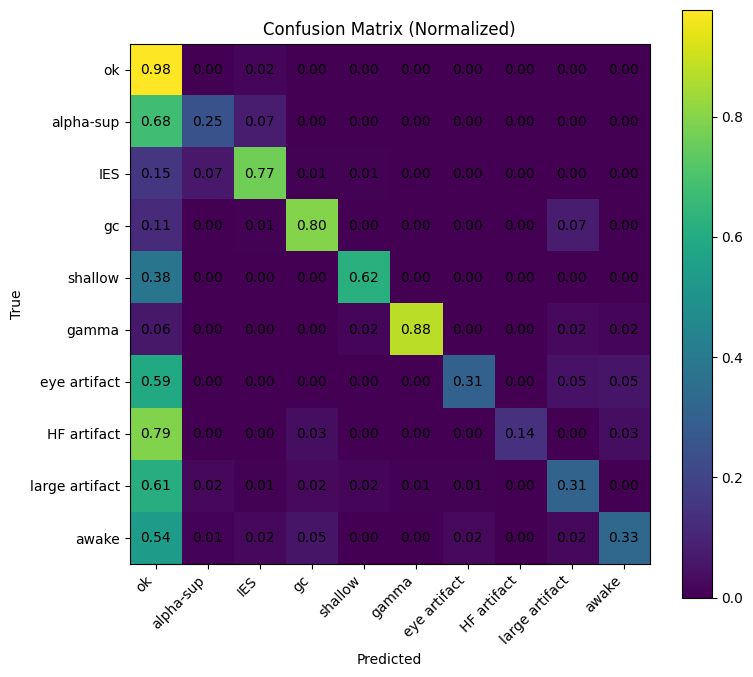

In [24]:

# ----------------------------
# Confusion matrix (time-bin level) on TEST
# ----------------------------
from sklearn.metrics import ConfusionMatrixDisplay

labels = list(range(NUM_CLASSES))
cm = confusion_matrix(y_test.astype(int), yhat_test.astype(int), labels=labels)

def plot_confusion_matrix(cm, class_names, normalize=True):
    cm_plot = cm.astype(np.float64)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, row_sums, where=row_sums != 0)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    # Annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = cm_plot[i, j]
            text = f"{value:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, text, ha="center", va="center")

    plt.tight_layout()
    plt.show()

classes = ["ok", "alpha-sup", "IES", "gc", "shallow", "gamma", "eye artifact", "HF artifact", "large artifact", 'awake']
plot_confusion_matrix(cm, classes, normalize = True)

# Visualize predicted mask

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


classes = ["ok", "alpha-sup", "IES", "gc", "shallow",
           "gamma", "eye artifact", "HF artifact",
           "large artifact", "awake"]

def annotate_mask(mask, class_names, title="Mask"):
    T = len(mask)

    plt.figure(figsize=(14, 2))
    plt.imshow(mask[None, :], aspect="auto")
    plt.yticks([])
    plt.title(title)

    # Find segment boundaries
    changes = np.where(mask[1:] != mask[:-1])[0] + 1
    segments = np.split(np.arange(T), changes)

    for seg in segments:
        start = seg[0]
        end = seg[-1]
        mid = (start + end) // 2
        label = class_names[mask[start]]
        plt.text(mid, 0, label,
                 ha="center", va="center",
                 fontsize=8, rotation=45)

    plt.tight_layout()
    plt.show()


def plot_spec_with_mask(x_log, mask, class_names, title):
    T = mask.shape[0]

    plt.figure(figsize=(14, 4))
    plt.imshow(x_log, aspect="auto", origin="lower")

    # Color bar for mask (transparent overlay)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(class_names))]

    for t in range(T):
        plt.axvspan(t, t+1, color=colors[mask[t]], alpha=0.08)

    # Legend
    patches = [mpatches.Patch(color=colors[i], label=class_names[i])
               for i in range(len(class_names))]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Freq bin")
    plt.tight_layout()
    plt.show()

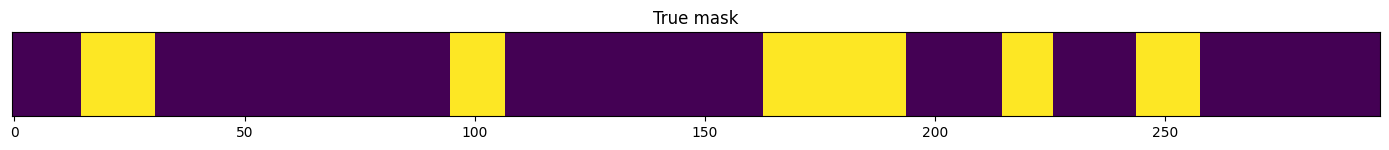

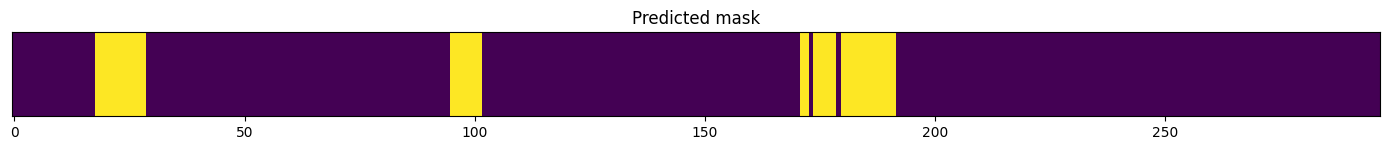

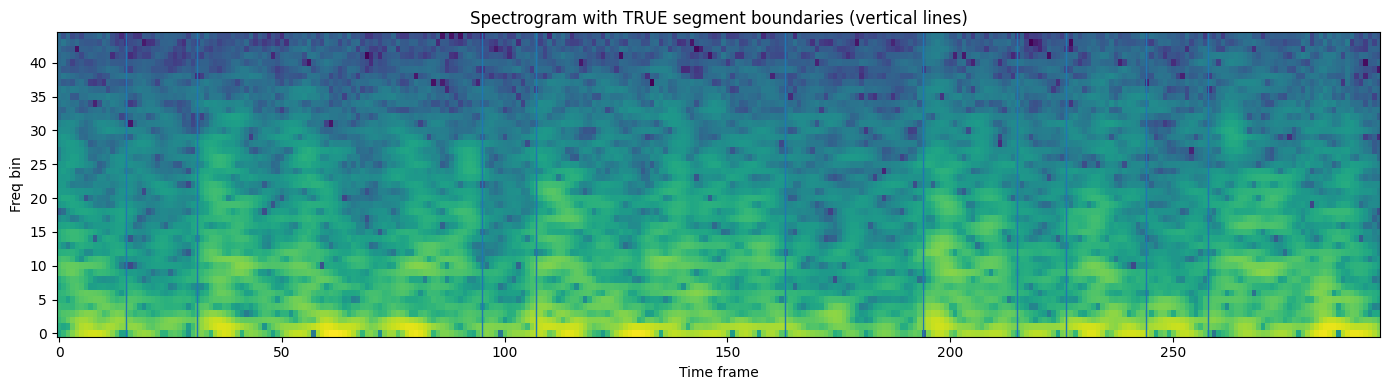

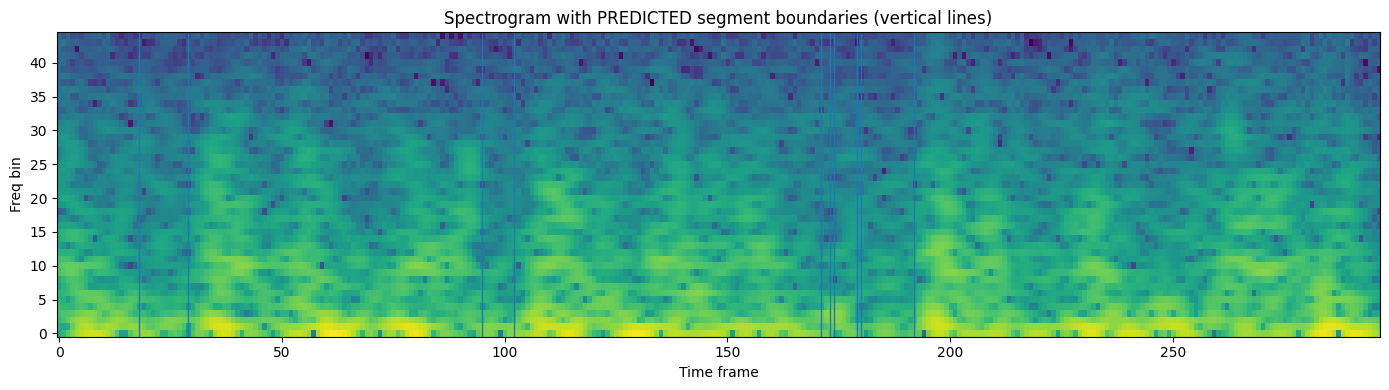

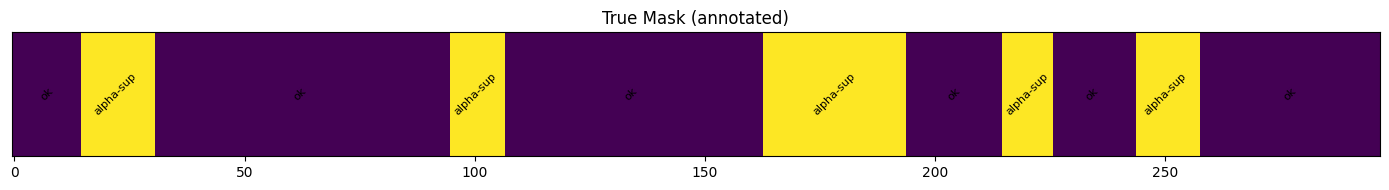

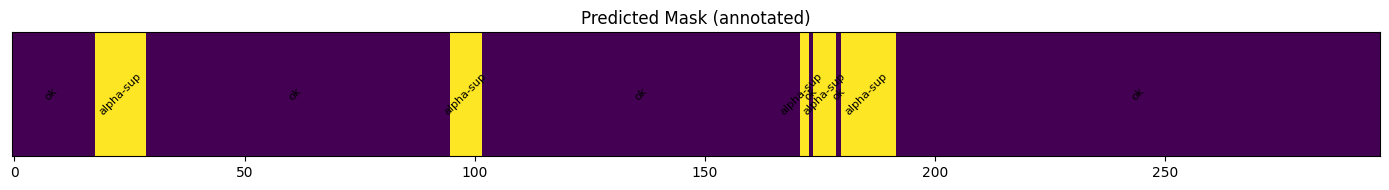

In [26]:
idx = 13

test_groups = pd.unique(gid_test)

# spectrogram
x_norm = np.log2(X_spec[test_groups[idx]] + 0.000001)


def get_pred_on_test_data(group_to_plot: int, p_all: np.ndarray, y_all: np.ndarray, yhat_all: np.ndarray,
                              gid_all: np.ndarray, title: str):
    m = gid_all == group_to_plot
    if not np.any(m):
        print("Group not found in this split:", group_to_plot)
        return

    p = p_all[m]                 # (T, C)
    y_true = y_all[m].astype(int)     # (T,)
    y_pred = yhat_all[m].astype(int)

    return y_true, y_pred, m

p_test = yhat_test_2s

# prediction
y_true, y_pred, m = get_pred_on_test_data(int(test_groups[idx]), p_test, y_test, yhat_test, gid_test, title="TEST (multiclass)")

# ---------- Masks as stripes ----------
plt.figure(figsize=(14, 1.6))
plt.imshow(y_true[None, :], aspect="auto")
plt.yticks([])
plt.title("True mask")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 1.6))
plt.imshow(y_pred[None, :], aspect="auto")
plt.yticks([])
plt.title("Predicted mask")
plt.tight_layout()
plt.show()

# ---------- Overlay mask boundaries on spectrogram ----------
def segment_boundaries(mask_1d: np.ndarray):
    # indices where label changes
    return np.where(mask_1d[1:] != mask_1d[:-1])[0] + 1

true_bounds = segment_boundaries(y_true)
pred_bounds = segment_boundaries(y_pred)

plt.figure(figsize=(14, 4))
plt.imshow(x_norm, aspect="auto", origin="lower")
for t in true_bounds:
    plt.axvline(t, linewidth=1)  # true boundaries
plt.title("Spectrogram with TRUE segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(x_norm, aspect="auto", origin="lower")
for t in pred_bounds:
    plt.axvline(t, linewidth=1)  # predicted boundaries
plt.title("Spectrogram with PREDICTED segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()


annotate_mask(y_true, classes, title="True Mask (annotated)")
annotate_mask(y_pred, classes, title="Predicted Mask (annotated)")

## Optional: Train LightGBM instead (swap-in)

If you prefer LGBM, set `USE_LGBM=True` below. (Keep everything else identical.)

In [27]:

# ----------------------------
# Optional: train LightGBM (MULTICLASS)
# ----------------------------
USE_LGBM = False

if USE_LGBM:
    # LightGBM can take class_weight directly; we reuse the same balanced weights as above.
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=8000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="multiclass",
        num_class=NUM_CLASSES,
        random_state=42,
        n_jobs=-1,
        class_weight=class_weight,
    )
    lgb_clf.fit(
        X_train, y_train.astype(int),
        eval_set=[(X_val, y_val.astype(int))],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
    )

    p_val = lgb_clf.predict_proba(X_val)
    p_test = lgb_clf.predict_proba(X_test)
    yhat_val = np.argmax(p_val, axis=1).astype(int)
    yhat_test = np.argmax(p_test, axis=1).astype(int)

    df_val = dice_multiclass_per_group(y_val, yhat_val, gid_val, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)
    df_test = dice_multiclass_per_group(y_test, yhat_test, gid_test, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)

    print("Val macro Dice (mean over recordings):", float(df_val["macro_dice"].mean()), " median:", float(df_val["macro_dice"].median()))
    print("Test macro Dice (mean over recordings):", float(df_test["macro_dice"].mean()), " median:", float(df_test["macro_dice"].median()))


# Visualise mask on test

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


classes = ["ok", "alpha-sup", "IES", "gc", "shallow",
           "gamma", "eye artifact", "HF artifact",
           "large artifact", "awake"]

def annotate_mask(mask, class_names, title="Mask"):
    T = len(mask)

    plt.figure(figsize=(14, 2))
    plt.imshow(mask[None, :], aspect="auto")
    plt.yticks([])
    plt.title(title)

    # Find segment boundaries
    changes = np.where(mask[1:] != mask[:-1])[0] + 1
    segments = np.split(np.arange(T), changes)

    for seg in segments:
        start = seg[0]
        end = seg[-1]
        mid = (start + end) // 2
        label = class_names[mask[start]]
        plt.text(mid, 0, label,
                 ha="center", va="center",
                 fontsize=8, rotation=45)

    plt.tight_layout()
    plt.show()


def plot_spec_with_mask(x_log, mask, class_names, title):
    T = mask.shape[0]

    plt.figure(figsize=(14, 4))
    plt.imshow(x_log, aspect="auto", origin="lower")

    # Color bar for mask (transparent overlay)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(class_names))]

    for t in range(T):
        plt.axvspan(t, t+1, color=colors[mask[t]], alpha=0.08)

    # Legend
    patches = [mpatches.Patch(color=colors[i], label=class_names[i])
               for i in range(len(class_names))]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Freq bin")
    plt.tight_layout()
    plt.show()

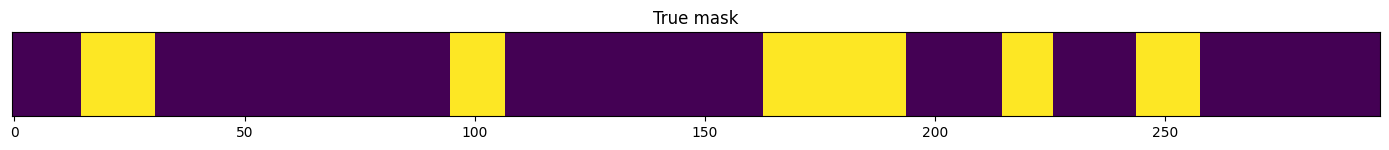

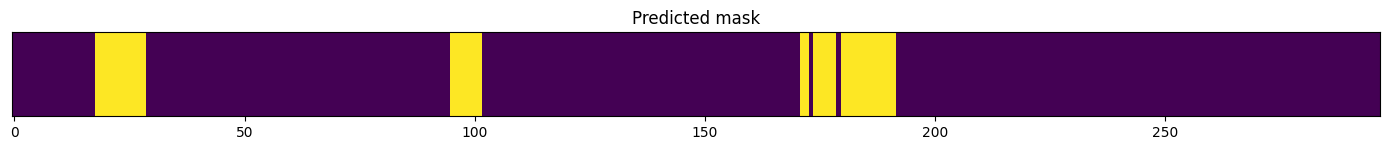

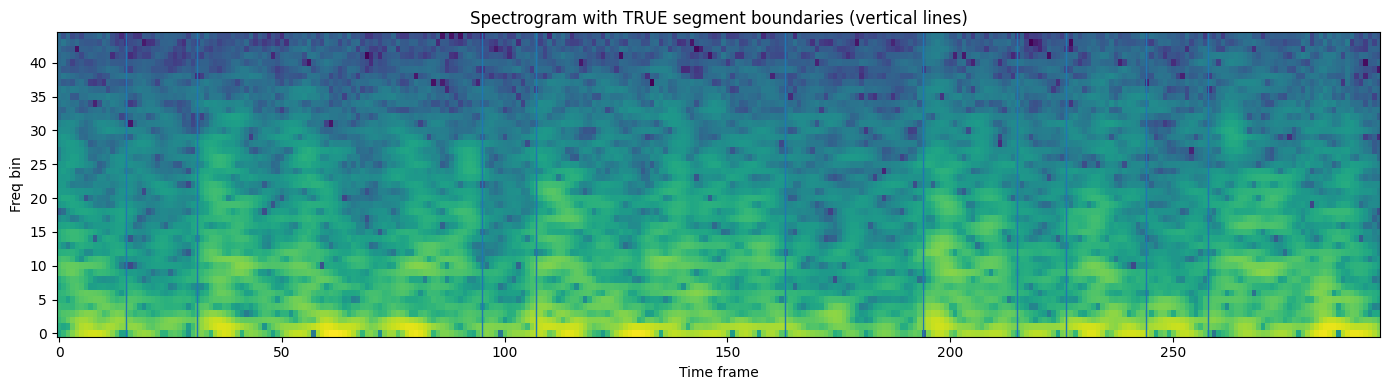

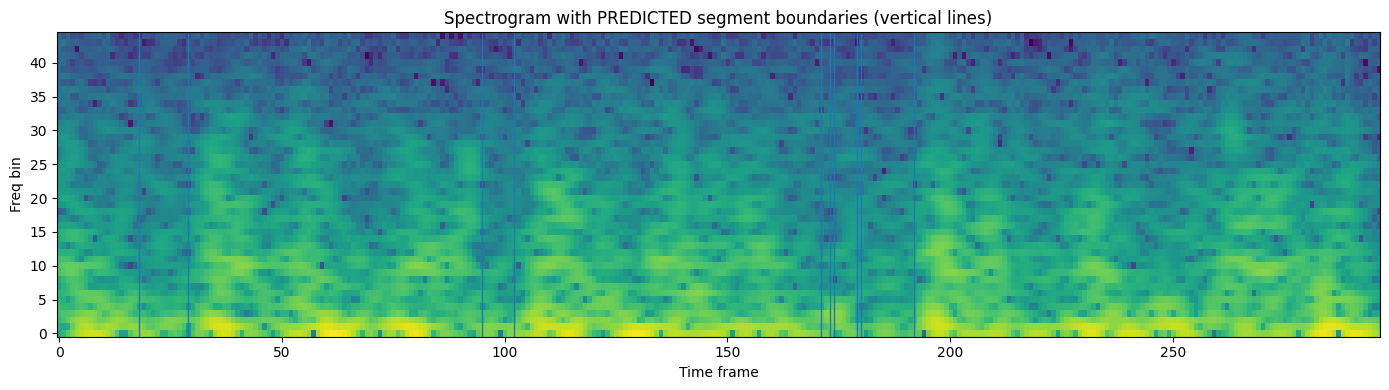

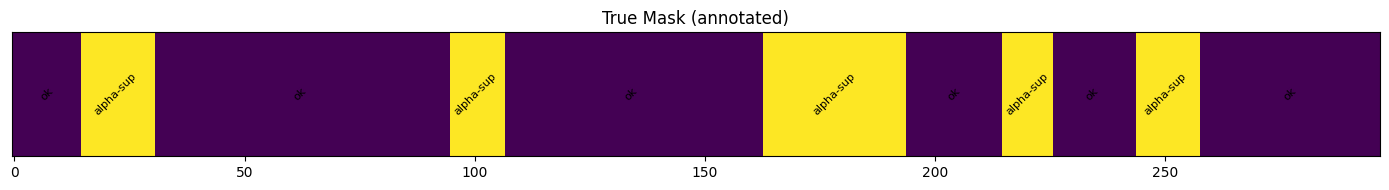

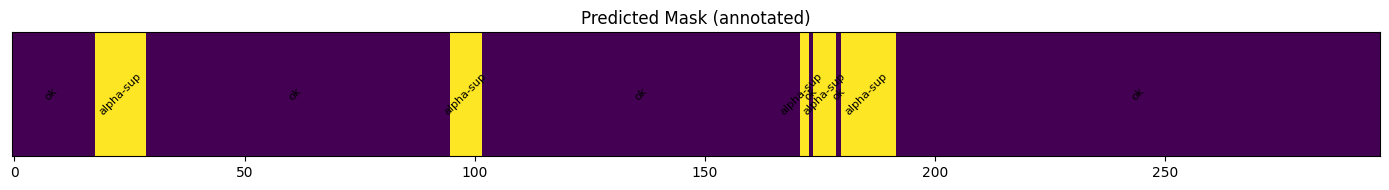

In [29]:
import pandas as pd
idx = 13

test_groups = pd.unique(gid_test)

# spectrogram
x_norm = np.log2(X_spec[test_groups[idx]] + 0.000001)


def get_pred_on_test_data(group_to_plot: int, p_all: np.ndarray, y_all: np.ndarray, yhat_all: np.ndarray,
                              gid_all: np.ndarray, title: str):
    m = gid_all == group_to_plot
    if not np.any(m):
        print("Group not found in this split:", group_to_plot)
        return

    p = p_all[m]                 # (T, C)
    y_true = y_all[m].astype(int)     # (T,)
    y_pred = yhat_all[m].astype(int)

    return y_true, y_pred, m


# prediction
y_true, y_pred, m = get_pred_on_test_data(int(test_groups[idx]), p_test, y_test, yhat_test, gid_test, title="TEST (multiclass)")

# ---------- Masks as stripes ----------
plt.figure(figsize=(14, 1.6))
plt.imshow(y_true[None, :], aspect="auto")
plt.yticks([])
plt.title("True mask")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 1.6))
plt.imshow(y_pred[None, :], aspect="auto")
plt.yticks([])
plt.title("Predicted mask")
plt.tight_layout()
plt.show()

# ---------- Overlay mask boundaries on spectrogram ----------
def segment_boundaries(mask_1d: np.ndarray):
    # indices where label changes
    return np.where(mask_1d[1:] != mask_1d[:-1])[0] + 1

true_bounds = segment_boundaries(y_true)
pred_bounds = segment_boundaries(y_pred)

plt.figure(figsize=(14, 4))
plt.imshow(x_norm, aspect="auto", origin="lower")
for t in true_bounds:
    plt.axvline(t, linewidth=1)  # true boundaries
plt.title("Spectrogram with TRUE segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(x_norm, aspect="auto", origin="lower")
for t in pred_bounds:
    plt.axvline(t, linewidth=1)  # predicted boundaries
plt.title("Spectrogram with PREDICTED segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()


annotate_mask(y_true, classes, title="True Mask (annotated)")
annotate_mask(y_pred, classes, title="Predicted Mask (annotated)")

## Visual check: reconstruction of predictions for one recording

We reconstruct the per-time predictions for a chosen `group_id` and plot probabilities + predicted mask vs true mask.

In [30]:

# ----------------------------
# Optional: plot per-time "confidence" (max class prob) + class labels over time for one test group
# ----------------------------
def plot_recording_multiclass(group_to_plot: int, p_all: np.ndarray, y_all: np.ndarray, yhat_all: np.ndarray,
                              gid_all: np.ndarray, title: str):
    m = gid_all == group_to_plot
    if not np.any(m):
        print("Group not found in this split:", group_to_plot)
        return

    p = p_all[m]                 # (T, C)
    y = y_all[m].astype(int)     # (T,)
    yhat = yhat_all[m].astype(int)

    conf = np.max(p, axis=1)     # (T,)
    pred_class = np.argmax(p, axis=1)

    fig, ax = plt.subplots(3, 1, figsize=(14, 5.5), sharex=True)
    ax[0].plot(conf)
    ax[0].set_title(f"{title} | group_id={group_to_plot} | max prob (confidence)")
    ax[0].set_ylabel("max softprob")

    ax[1].plot(y, label="true")
    ax[1].plot(yhat, label="pred", alpha=0.8)
    ax[1].set_ylabel("class")
    ax[1].legend()

    ax[2].plot(pred_class, alpha=0.9)
    ax[2].set_ylabel("argmax(p)")
    ax[2].set_xlabel("time index")

    plt.tight_layout()
    plt.show()

test_groups = pd.unique(gid_test)
if len(test_groups) > 0:
    g0 = int(test_groups[idx])
    plot_recording_multiclass(g0, p_test, y_test, yhat_test, gid_test, title="TEST (multiclass)")


AxisError: axis 1 is out of bounds for array of dimension 1